In [1]:
import math
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.nn.functional as F
import os
import time
from tqdm.auto import tqdm

import sys
sys.path.insert(0, "/home/palakons/shapevae")#files are relative to singularity home, coz the server is running singularity from there
from model.ptv3_based_model import PointVAE, VAEConfig


from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Subset
from pytorch3d.loss import chamfer_distance
import numpy as np

import wandb




# autoreload py
%load_ext autoreload
%autoreload 2

/home/palakons/.conda/envs/pro_pt3d/lib/python3.10/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


/home/palakons/.conda/envs/pro_pt3d/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/home/palakons/.conda/envs/pro_pt3d/compiler_compat/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status


In [9]:

from experiment_runner import ExperimentConfig, run_training
from shapenet_dataset import ShapeNetDataset
from visualize import visualize_reconstructions, plot_pointclouds

from model.ptv3_based_model import PointVAE, VAEConfig,check_voxel_collisions
from model.losses import repulsion_exp_loss,loss_fn_cd_plus_real_repulsion,loss_fn_cd,loss_fn_cd_plus_repulsion
from model.base_model import PointCloudAE

# from shapevae.visualize import visualize_interpolations

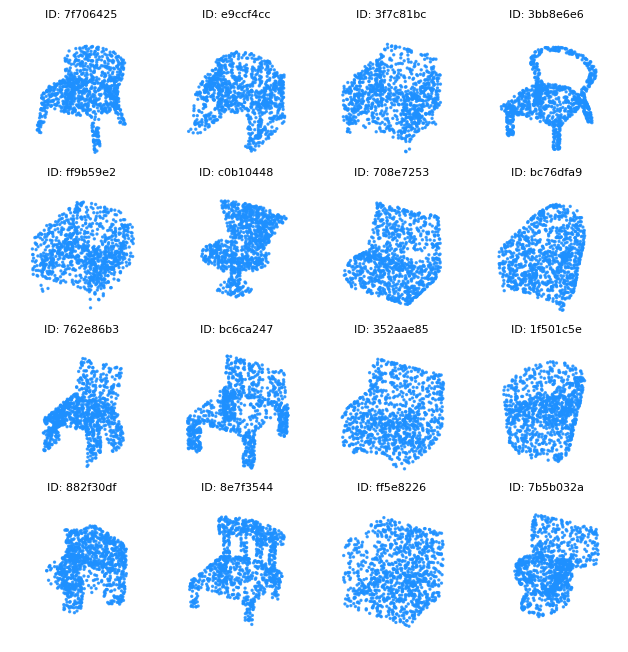

In [3]:
# raw mesh loader was very slow, precompute pointcloud as .npy instead
# precompute with ```python precompute_pointcloud.py --data-dir /ist/ist-share/scads/ploy/scene2/big_file/shapenet/shapenet/ --object-class 03001627 --output-dir ./sampled_poincloud/ --num-points 1024```

dataset = ShapeNetDataset(data_dir='./shapevae/sampled_poincloud/', object_class='03001627')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# plot 3d scatter of first batch
for batch in dataloader:
    pcs = batch['points']  # shape (B, N, 3)
    ids = batch['object_id']
    pc_list = list(zip(ids, pcs))
    plot_pointclouds(pc_list)
    break

## Setting up

In [4]:

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# Shared configs for all runs
z_dim = 1024
batch_size = 16
num_epochs = 100
lr = 1e-3
val_split = 0.1
seed = 42
run_root="/shapevae_weights"

# Notebook-safe default: multiprocessing DataLoader workers can trigger
# "can only test a child process" cleanup errors in Jupyter.
num_workers = 0

torch.manual_seed(seed)
np.random.seed(seed)

num_points = dataset[0]["points"].shape[0]
all_indices = np.arange(len(dataset))
train_idx, val_idx = train_test_split(
    all_indices, test_size=val_split, random_state=seed, shuffle=True
)
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True, num_workers=num_workers,
    pin_memory=(device == "cuda"),
)
val_loader = DataLoader(
    val_set,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=(device == "cuda"),
)


device: cuda


Found 7 runs in wandb project.
ptv3_cd_plus_repulsion wekb8cpr 100
ptv3_cd_norepulsion 0t8jh988 100
ptv3_cd_vae_repulsion ac2iel2z 100
ptv3_cd_vae_norepulsion hhugub0f 100
baseline_cd imdykapz 100
    Visualizing interpolations... baseline_cd


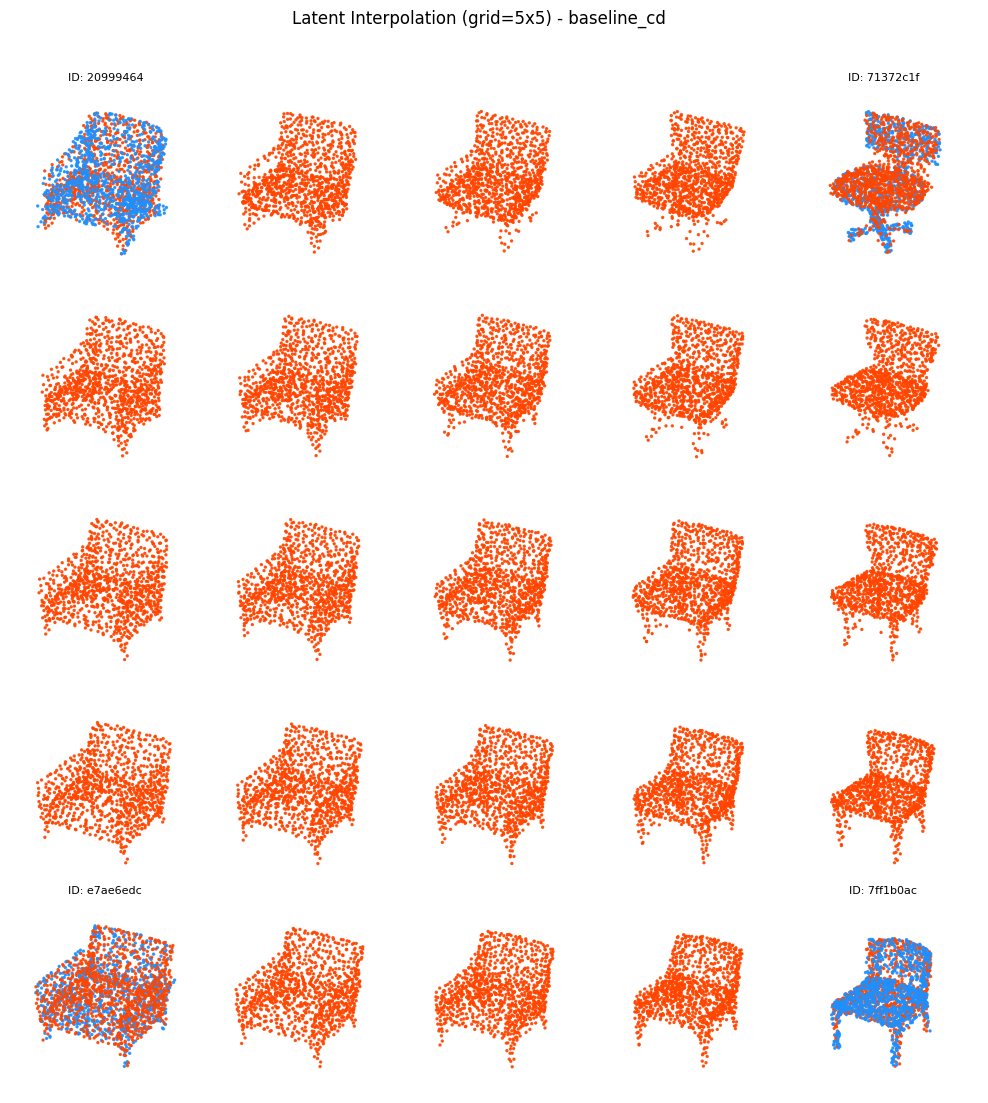

baseline_cd_plus_repulsion_skeleton onj93j3d 100
    Visualizing interpolations... baseline_cd_plus_repulsion_skeleton


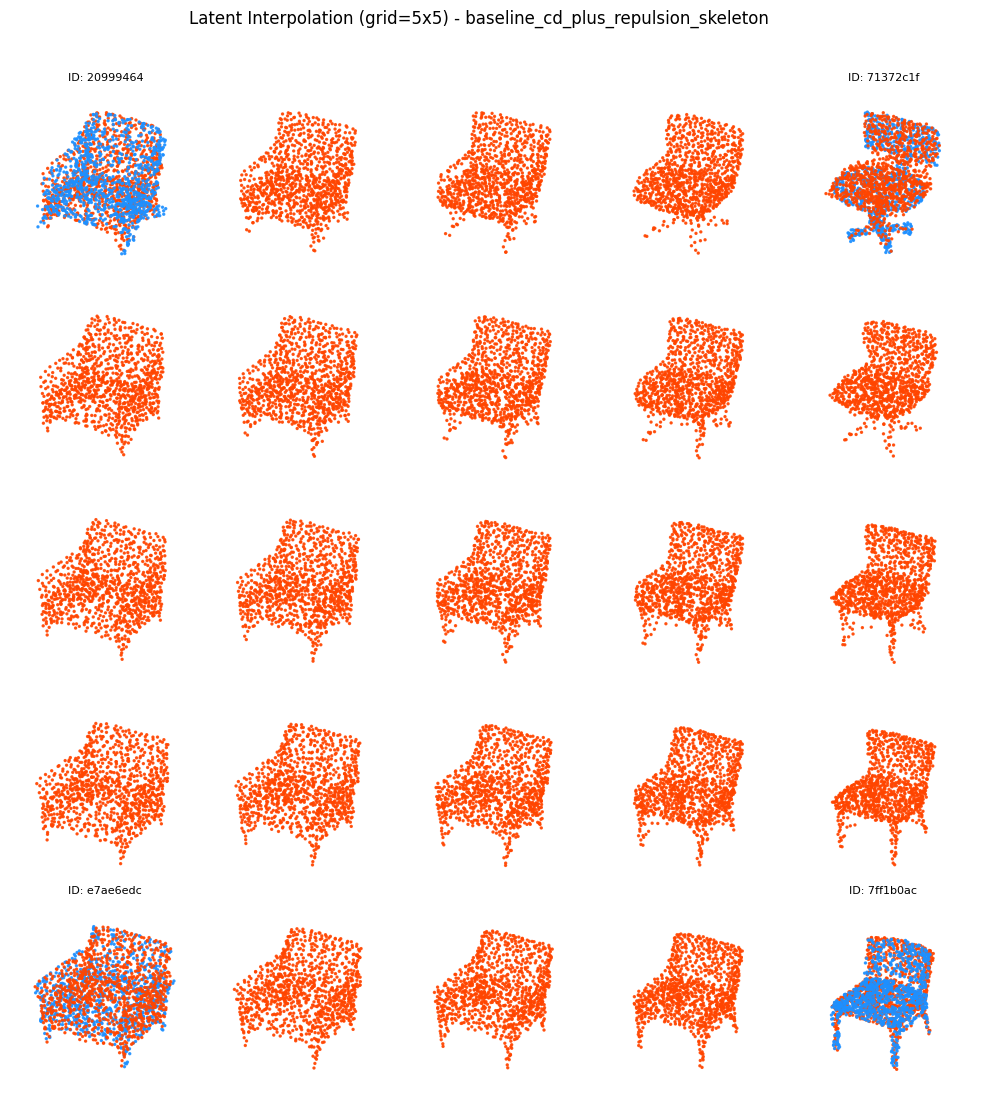

ptv3_cd_plus_repulsion gkpchxup 67


In [ ]:


api = wandb.Api()
runs = api.runs("palakon-k/shapevae")

print(f"Found {len(runs)} runs in wandb project.")

for run in runs:
    #check for run_dir in run summary
    # print(run.name, run.id,run.summary['epoch'] )
    if "run_dir" in run.summary and run.summary['epoch'] == 100: # only check checkpoints for runs that completed full training
        # print("  run_dir:", run.summary["run_dir"]) 
        best_checkpoint_path = os.path.join(run.summary["run_dir"], "checkpoints/best.pt")
        if os.path.exists(best_checkpoint_path):
            # print("    Found checkpoint:", best_checkpoint_path)
            checkpoint = torch.load(best_checkpoint_path, map_location=device)
            # print(f"keys in checkpoint: {checkpoint.keys()}") #['epoch', 'best_val', 'model_state_dict', 'optimizer_state_dict', 'config']
            model_state_dict = checkpoint["model_state_dict"]
            if "ptv3" in run.name:
                cfg = VAEConfig(hidden_dim=64, latent_dim=128, num_points=num_points, variational=("vae" in run.name)   , grid_size=.01)
                model = PointVAE(cfg=cfg).to(device)
            elif "baseline" in run.name:

                model = PointCloudAE(z_dim=z_dim, num_points=num_points)
            else:
                print("    Unrecognized model type in run name. Skipping visualization.")
                continue

            model.load_state_dict(model_state_dict)
            model.to(device)
            model.eval()
            # Visualize interpolations for this model
            visualize_interpolations(model, val_loader, device=device,title=run.name)
        else:
            print("    Checkpoint not found. Skipping visualization.")